In [2]:
#import liberies
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("/content/house_price.csv")

In [4]:
df.head()

,area,rooms,price
0,2104,3,399900
1,1600,3,329900
2,2400,3,369000
3,1416,2,232000
4,3000,4,539900


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    47 non-null     int64
 1   rooms   47 non-null     int64
 2   price   47 non-null     int64
dtypes: int64(3)
memory usage: 1.2 KB


In [7]:
df.isnull().sum()

,0
area,0
rooms,0
price,0


In [8]:
(df == 0).sum()

,0
area,0
rooms,0
price,0


In [9]:
df.shape

(47, 3)

In [10]:
df.describe()

,area,rooms,price
count,47.000000,47.000000,47.000000
mean,2000.680851,3.170213,340412.659574
std,794.702354,0.760982,125039.899586
min,852.000000,1.000000,169900.000000
25%,1432.000000,3.000000,249900.000000
50%,1888.000000,3.000000,299900.000000
75%,2269.000000,4.000000,384450.000000
max,4478.000000,5.000000,699900.000000


In [23]:
df['price'].describe()

,price
count,47.000000
mean,340412.659574
std,125039.899586
min,169900.000000
25%,249900.000000
50%,299900.000000
75%,384450.000000
max,699900.000000


<Axes: xlabel='price', ylabel='Count'>

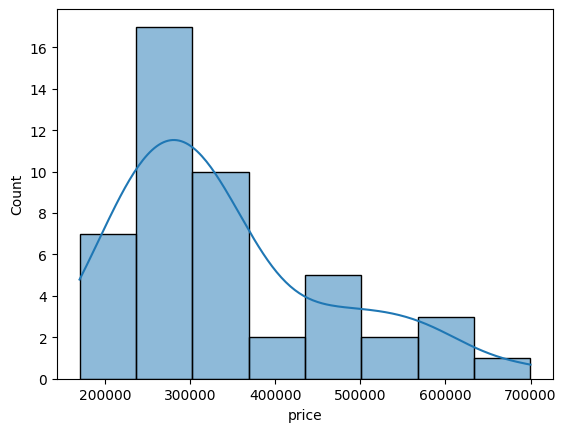

In [24]:
sns.histplot(df['price'], kde = True)

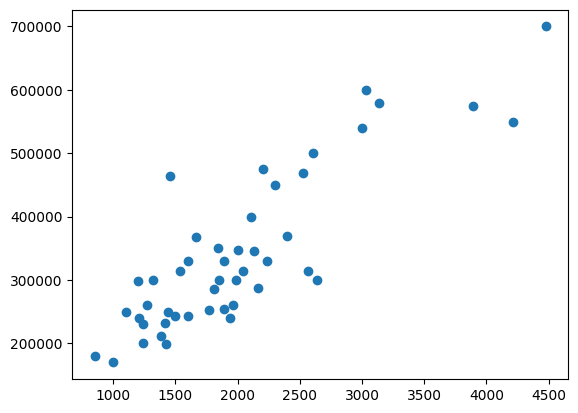

In [25]:
plt.scatter( df['area'], df['price'])

In [26]:
corr = df.corr()

In [27]:
corr

,area,rooms,price
area,1.000000,0.559967,0.854988
rooms,0.559967,1.000000,0.442261
price,0.854988,0.442261,1.000000


<Axes: >

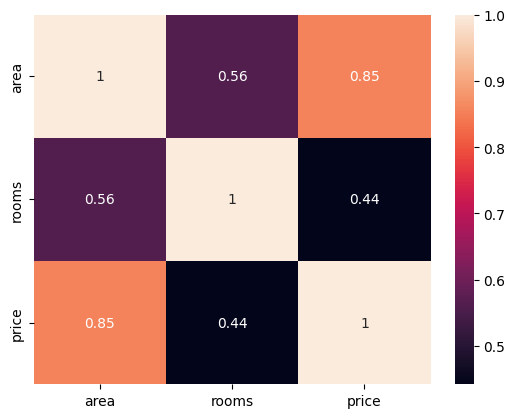

In [28]:
sns.heatmap(corr, annot=True)

In [29]:
x = df[['area']]
y = df['price']

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [31]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, mean_absolute_error

In [39]:
model = LinearRegression()

In [40]:
model.fit(x_train, y_train)

LinearRegression()

In [41]:
y_pred = model.predict(x_test)

In [46]:
comparsion = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparsion.head()

,Actual,Predicted
27,469000,399158.368302
39,287000,350252.262965
26,464500,255664.630663
43,299000,221000.413144
24,573900,582421.905887


Text(0.5, 1.0, 'Actual vs Predicted')

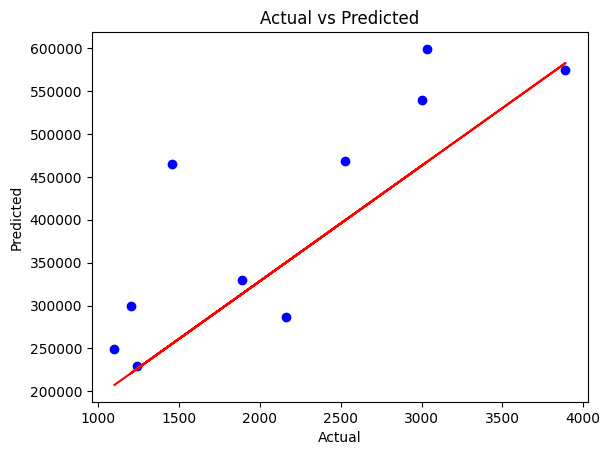

In [51]:
#now draw a line that shows scatter plot
plt.scatter(x_test, y_test, color = 'blue')
plt.plot(x_test, y_pred, color = 'red')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')

In [55]:
#accuracy measurs
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Absolute Error: 69978.50296543419
Mean Squared Error: 8407789060.4898405
R-squared: 0.526301453884142
